In [26]:
# Load the hotel reviews from CSV
import pandas as pd
import time
# importing time so the start and end time can be used to calculate file loading time
print("Loading data file now, this could take a while depending on file size")
start = time.time()
# df is 'DataFrame' - make sure you downloaded the file to the data folder
df = pd.read_csv('../../../archive/Hotel_Reviews.csv')
end = time.time()
print("Loading took " + str(round(end - start, 2)) + " seconds")

Loading data file now, this could take a while depending on file size
Loading took 1.54 seconds


In [27]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='str')

In [28]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


In [29]:
print(len(df['Reviewer_Nationality'].unique()),sorted(df['Reviewer_Nationality'].unique()))

227 [' ', ' Abkhazia Georgia ', ' Afghanistan ', ' Albania ', ' Algeria ', ' American Samoa ', ' Andorra ', ' Angola ', ' Anguilla ', ' Antarctica ', ' Antigua Barbuda ', ' Argentina ', ' Armenia ', ' Aruba ', ' Australia ', ' Austria ', ' Azerbaijan ', ' Bahamas ', ' Bahrain ', ' Bangladesh ', ' Barbados ', ' Belarus ', ' Belgium ', ' Belize ', ' Benin ', ' Bermuda ', ' Bhutan ', ' Bolivia ', ' Bonaire St Eustatius and Saba ', ' Bosnia and Herzegovina ', ' Botswana ', ' Brazil ', ' British Virgin Islands ', ' Brunei ', ' Bulgaria ', ' Burundi ', ' Cambodia ', ' Cameroon ', ' Canada ', ' Cape Verde ', ' Cayman Islands ', ' Central Africa Republic ', ' Chile ', ' China ', ' Cocos K I ', ' Colombia ', ' Comoros ', ' Congo ', ' Cook Islands ', ' Costa Rica ', ' Crimea ', ' Croatia ', ' Cura ao ', ' Cyprus ', ' Czech Republic ', ' Democratic Republic of the Congo ', ' Denmark ', ' Djibouti ', ' Dominica ', ' Dominican Republic ', ' East Timor ', ' Ecuador ', ' Egypt ', ' El Salvador ', ' E

In [30]:
number_of_reviews = df.groupby('Reviewer_Nationality',sort=True).size().sort_values(ascending=False)
countries = number_of_reviews.keys()

In [31]:
number_of_reviews,countries

(Reviewer_Nationality
 United Kingdom               245246
 United States of America      35437
 Australia                     21686
 Ireland                       14827
 United Arab Emirates          10235
                               ...  
 Palau                             1
 Northern Mariana Islands          1
 Svalbard Jan Mayen                1
 Tuvalu                            1
 Vatican City                      1
 Length: 227, dtype: int64,
 Index([' United Kingdom ', ' United States of America ', ' Australia ',
        ' Ireland ', ' United Arab Emirates ', ' Saudi Arabia ',
        ' Netherlands ', ' Switzerland ', ' Germany ', ' Canada ',
        ...
        ' Niger ', ' Anguilla ', ' Guinea ', ' Cape Verde ', ' Comoros ',
        ' Palau ', ' Northern Mariana Islands ', ' Svalbard Jan Mayen ',
        ' Tuvalu ', ' Vatican City '],
       dtype='str', name='Reviewer_Nationality', length=227))

In [32]:
import matplotlib.pyplot as plt

<Axes: xlabel='Reviewer_Nationality'>

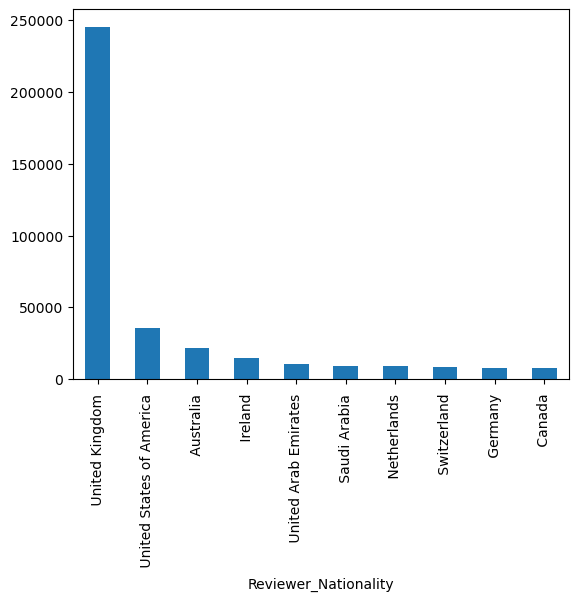

In [33]:
number_of_reviews.head(10).plot(kind='bar')

In [34]:
uk_reviews = df[df['Reviewer_Nationality']==countries[0]].groupby('Hotel_Name',sort=True).size().sort_values(ascending=False)

<Axes: xlabel='Hotel_Name'>

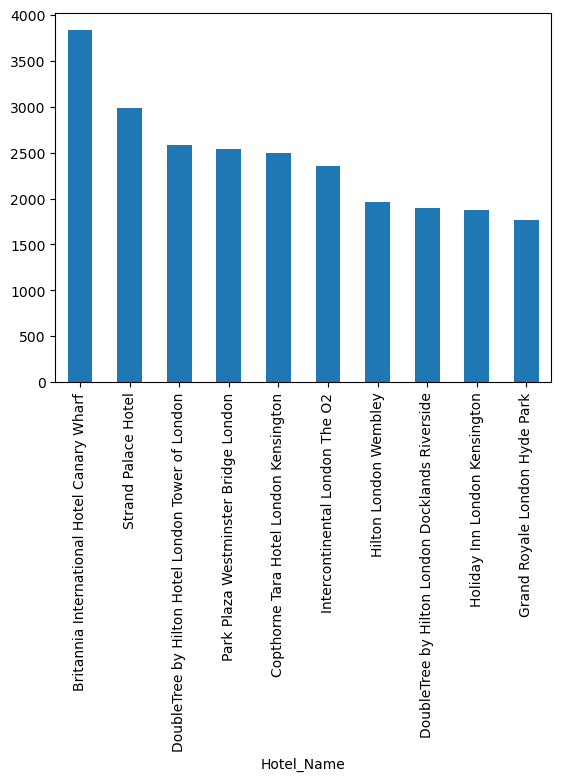

In [35]:
uk_reviews.head(10).plot(kind='bar')

In [36]:
uk_reviews.index[0]

'Britannia International Hotel Canary Wharf'

In [37]:
most_hotel = []
for i in range(10):
    hotel = df[df['Reviewer_Nationality']==countries[i]].groupby('Hotel_Name',sort=True).size().sort_values(ascending=False).index[0]
    review = df[df['Reviewer_Nationality']==countries[i]].groupby('Hotel_Name',sort=True).size().sort_values(ascending=False).iloc[0]
    most_hotel.append([countries[i],hotel,review])
    print(f"{countries[i]} \t\t {hotel} \t\t {review}")

 United Kingdom  		 Britannia International Hotel Canary Wharf 		 3833
 United States of America  		 Hotel Esther a 		 423
 Australia  		 Park Plaza Westminster Bridge London 		 167
 Ireland  		 Copthorne Tara Hotel London Kensington 		 239
 United Arab Emirates  		 Millennium Hotel London Knightsbridge 		 129
 Saudi Arabia  		 The Cumberland A Guoman Hotel 		 142
 Netherlands  		 Jaz Amsterdam 		 97
 Switzerland  		 Hotel Da Vinci 		 97
 Germany  		 Hotel Da Vinci 		 86
 Canada  		 St James Court A Taj Hotel London 		 61


In [38]:
df['Calc_Total_Number_of_Reviews'] = df.groupby('Hotel_Name')['Hotel_Name'].transform('count')
df.groupby('Hotel_Name')[['Total_Number_of_Reviews', 'Calc_Total_Number_of_Reviews']].mean().sort_values('Calc_Total_Number_of_Reviews',ascending=False)

,Total_Number_of_Reviews,Calc_Total_Number_of_Reviews
Hotel_Name,,
Britannia International Hotel Canary Wharf,9086.0,4789.0
Strand Palace Hotel,9568.0,4256.0
Park Plaza Westminster Bridge London,12158.0,4169.0
Copthorne Tara Hotel London Kensington,7105.0,3578.0
DoubleTree by Hilton Hotel London Tower of London,7491.0,3212.0
...,...,...
Ibis Styles Milano Palmanova,207.0,12.0
Le Lavoisier,66.0,12.0
Hotel Wagner,135.0,10.0


In [39]:
df['Calc_Average_Score'] = df.groupby('Hotel_Name')['Reviewer_Score'].transform('mean').round(1)

In [40]:
df[['Calc_Average_Score','Average_Score']]

,Calc_Average_Score,Average_Score
0,7.8,7.7
1,7.8,7.7
2,7.8,7.7
3,7.8,7.7
4,7.8,7.7
...,...,...
515733,7.8,8.1
515734,7.8,8.1
515735,7.8,8.1
515736,7.8,8.1


In [41]:
df['Calc_Average_Score'].mean(), df['Average_Score'].mean(), df[['Calc_Average_Score', 'Average_Score']].corr()

(np.float64(8.39529470390004),
 np.float64(8.39748690226433),
                     Calc_Average_Score  Average_Score
 Calc_Average_Score             1.00000        0.98198
 Average_Score                  0.98198        1.00000)

In [42]:
comparison = df.groupby('Hotel_Name')[['Average_Score', 'Calc_Average_Score']].mean()
comparison['Diff'] = comparison['Calc_Average_Score'] - comparison['Average_Score']
comparison.sort_values('Diff', ascending=False)

,Average_Score,Calc_Average_Score,Diff
Hotel_Name,,,
Best Western Hotel Astoria,7.7,8.5,0.8
Hotel Stendhal Place Vend me Paris MGallery by Sofitel,8.8,9.5,0.7
Mercure Paris Porte d Orleans,7.5,8.2,0.7
Renaissance Paris Vendome Hotel,7.9,8.6,0.7
Hotel Royal Elys es,7.0,7.5,0.5
...,...,...,...
Hotel La Spezia Gruppo MiniHotel,8.4,7.7,-0.7
Holiday Inn Paris Montparnasse Pasteur,7.1,6.3,-0.8
MARQUIS Faubourg St Honor Relais Ch teaux,8.6,7.7,-0.9


In [43]:
start = time.time()
noneg = df[df['Negative_Review'] == 'No Negative']
nopos = df[df['Positive_Review'] == 'No Positive'] 
nonegpos = df[(df['Negative_Review'] == 'No Negative') & (df['Positive_Review'] == 'No Positive')]
end = time.time()
noneg.shape, nopos.shape, nonegpos.shape, round(end - start,2)

((127890, 19), (35946, 19), (127, 19), 0.16)

## Part 5

In [44]:
df = df.drop(columns=['lat','lng','Additional_Number_of_Scoring'])

In [45]:
def replace_address(row):
    if "Netherlands" in row["Hotel_Address"]:
        return "Amsterdam, Netherlands"
    elif "Barcelona" in row["Hotel_Address"]:
        return "Barcelona, Spain"
    elif "United Kingdom" in row["Hotel_Address"]:
        return "London, United Kingdom"
    elif "Milan" in row["Hotel_Address"]:        
        return "Milan, Italy"
    elif "France" in row["Hotel_Address"]:
        return "Paris, France"
    elif "Vienna" in row["Hotel_Address"]:
        return "Vienna, Austria" 
    
# Replace all the addresses with a shortened, more useful form
df["Hotel_Address"] = df.apply(replace_address, axis = 1)
# The sum of the value_counts() should add up to the total number of reviews
print(df["Hotel_Address"].value_counts())

Hotel_Address
London, United Kingdom    262301
Barcelona, Spain           60149
Paris, France              59928
Amsterdam, Netherlands     57214
Vienna, Austria            38939
Milan, Italy               37207
Name: count, dtype: int64


In [46]:
display(df.groupby("Hotel_Address").agg({"Hotel_Name": "nunique"}))

,Hotel_Name
Hotel_Address,
"Amsterdam, Netherlands",105
"Barcelona, Spain",211
"London, United Kingdom",400
"Milan, Italy",162
"Paris, France",458
"Vienna, Austria",158


In [47]:
df['Total_Number_of_Reviews'] = df['Calc_Total_Number_of_Reviews']
df = df.drop(columns='Calc_Total_Number_of_Reviews')
df['Average_Score'] = df['Calc_Average_Score']
df = df.drop(columns='Calc_Average_Score')

In [48]:
df = df.drop(columns=["Review_Total_Negative_Word_Counts", "Review_Total_Positive_Word_Counts", "Review_Date","days_since_review"])

In [49]:
df = df.drop(columns=['Total_Number_of_Reviews_Reviewer_Has_Given'])

In [50]:
df.head

<bound method NDFrame.head of                  Hotel_Address  Average_Score             Hotel_Name  \
0       Amsterdam, Netherlands            7.8            Hotel Arena   
1       Amsterdam, Netherlands            7.8            Hotel Arena   
2       Amsterdam, Netherlands            7.8            Hotel Arena   
3       Amsterdam, Netherlands            7.8            Hotel Arena   
4       Amsterdam, Netherlands            7.8            Hotel Arena   
...                        ...            ...                    ...   
515733         Vienna, Austria            7.8  Atlantis Hotel Vienna   
515734         Vienna, Austria            7.8  Atlantis Hotel Vienna   
515735         Vienna, Austria            7.8  Atlantis Hotel Vienna   
515736         Vienna, Austria            7.8  Atlantis Hotel Vienna   
515737         Vienna, Austria            7.8  Atlantis Hotel Vienna   

       Reviewer_Nationality  \
0                   Russia    
1                  Ireland    
2           

In [51]:
# Remove opening and closing brackets
df.Tags = df.Tags.str.strip("[']")
# remove all quotes too
df.Tags = df.Tags.str.replace(" ', '", ",", regex = False)

In [52]:
# Process the Tags into new columns
# The file Hotel_Reviews_Tags.py, identifies the most important tags
# Leisure trip, Couple, Solo traveler, Business trip, Group combined with Travelers with friends, 
# Family with young children, Family with older children, With a pet
df["Leisure_trip"] = df.Tags.apply(lambda tag: 1 if "Leisure trip" in tag else 0)
df["Couple"] = df.Tags.apply(lambda tag: 1 if "Couple" in tag else 0)
df["Solo_traveler"] = df.Tags.apply(lambda tag: 1 if "Solo traveler" in tag else 0)
df["Business_trip"] = df.Tags.apply(lambda tag: 1 if "Business trip" in tag else 0)
df["Group"] = df.Tags.apply(lambda tag: 1 if "Group" in tag or "Travelers with friends" in tag else 0)
df["Family_with_young_children"] = df.Tags.apply(lambda tag: 1 if "Family with young children" in tag else 0)
df["Family_with_older_children"] = df.Tags.apply(lambda tag: 1 if "Family with older children" in tag else 0)
df["With_a_pet"] = df.Tags.apply(lambda tag: 1 if "With a pet" in tag else 0)

In [56]:
df.head(5)

,Hotel_Address,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Total_Number_of_Reviews,Positive_Review,Reviewer_Score,Tags,Leisure_trip,Couple,Solo_traveler,Business_trip,Group,Family_with_young_children,Family_with_older_children,With_a_pet
0,"Amsterdam, Netherlands",7.8,Hotel Arena,Russia,I am so angry that i made this post available...,405,Only the park outside of the hotel was beauti...,2.9,"Leisure trip, Couple, Duplex Double Room, Sta...",1,1,0,0,0,0,0,0
1,"Amsterdam, Netherlands",7.8,Hotel Arena,Ireland,No Negative,405,No real complaints the hotel was great great ...,7.5,"Leisure trip, Couple, Duplex Double Room, Sta...",1,1,0,0,0,0,0,0
2,"Amsterdam, Netherlands",7.8,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,405,Location was good and staff were ok It is cut...,7.1,"Leisure trip, Family with young children, Dup...",1,0,0,0,0,1,0,0
3,"Amsterdam, Netherlands",7.8,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,405,Great location in nice surroundings the bar a...,3.8,"Leisure trip, Solo traveler, Duplex Double Ro...",1,0,1,0,0,0,0,0
4,"Amsterdam, Netherlands",7.8,Hotel Arena,New Zealand,You When I booked with your company on line y...,405,Amazing location and building Romantic setting,6.7,"Leisure trip, Couple, Suite, Stayed 2 nights,...",1,1,0,0,0,0,0,0


In [54]:
# Saving new data file with calculated columns
print("Saving results to Hotel_Reviews_Filtered.csv")
df.to_csv(r'../../../archive/Hotel_Reviews_Filtered.csv', index = False)
end = time.time()
print("Filtering took " + str(round(end - start, 2)) + " seconds")


Saving results to Hotel_Reviews_Filtered.csv
Filtering took 759.75 seconds
